In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import joblib
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/archive/fraudTrain_cleaned.csv')

In [ ]:
df_train.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,merch_lat,merch_long,is_fraud,datetime,hour,day_of_week,month,is_weekend,time_of_day,amt_bin
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.011293,-82.048315,0,2019-01-01 00:00:18,0,1,1,0,Night,$0-50
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,49.159047,-118.186462,0,2019-01-01 00:00:44,0,1,1,0,Night,$100-200
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,43.150704,-112.154481,0,2019-01-01 00:00:51,0,1,1,0,Night,$200-500
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,47.034331,-112.561071,0,2019-01-01 00:01:16,0,1,1,0,Night,$0-50
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.674999,-78.632459,0,2019-01-01 00:03:06,0,1,1,0,Night,$0-50


In [ ]:
df_train.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'datetime', 'hour', 'day_of_week', 'month',
       'is_weekend', 'time_of_day', 'amt_bin'],
      dtype='object')

In [ ]:
df_train.columns.tolist()

['trans_date_trans_time',
 'cc_num',
 'merchant',
 'category',
 'amt',
 'first',
 'last',
 'gender',
 'street',
 'city',
 'state',
 'zip',
 'lat',
 'long',
 'city_pop',
 'job',
 'dob',
 'trans_num',
 'unix_time',
 'merch_lat',
 'merch_long',
 'is_fraud',
 'datetime',
 'hour',
 'day_of_week',
 'month',
 'is_weekend',
 'time_of_day',
 'amt_bin']

In [ ]:
user_category = df_train.groupby(['cc_num', 'category'])['amt'].sum().unstack(fill_value=0)

print(f"Number of users: {len(user_category)}")
print(f"Number of categories: {len(user_category.columns)}")
user_category.head()

Number of users: 983
Number of categories: 14


category,entertainment,food_dining,gas_transport,grocery_net,grocery_pos,health_fitness,home,kids_pets,misc_net,misc_pos,personal_care,shopping_net,shopping_pos,travel
cc_num,,,,,,,,,,,,,,
60416207185,5327.22,2353.95,13221.64,2670.81,14646.56,4241.94,7604.69,6671.92,3020.70,4838.97,5629.21,3515.72,10893.96,406.18
60422928733,6857.47,9870.48,10121.71,2407.72,14740.06,4687.39,10213.69,11821.96,4037.81,6038.31,6036.51,9475.63,8832.35,499.11
60423098130,2290.18,2248.67,3641.47,37.27,5335.87,1708.76,1854.30,2741.89,1471.80,1141.46,2061.65,5262.95,1629.83,27247.53
60427851591,2985.29,1528.00,2081.52,1142.46,7818.85,2550.97,4798.08,2242.31,4213.20,1635.23,1553.62,9500.07,6355.39,10724.62
60487002085,1495.84,1884.46,3637.95,1009.63,4028.14,2270.87,2191.04,2641.24,192.06,2900.79,817.60,557.37,1444.32,88.80


In [ ]:
user_category_pct = user_category.div(user_category.sum(axis=1), axis=0) * 100

print("User spending % by category:")
user_category_pct.head()

User spending % by category:


category,entertainment,food_dining,gas_transport,grocery_net,grocery_pos,health_fitness,home,kids_pets,misc_net,misc_pos,personal_care,shopping_net,shopping_pos,travel
cc_num,,,,,,,,,,,,,,
60416207185,6.264114,2.767937,15.546920,3.140523,17.222439,4.987967,8.942121,7.845305,3.551948,5.689996,6.619215,4.134027,12.809872,0.477615
60422928733,6.491345,9.343489,9.581305,2.279170,13.953078,4.437127,9.668374,11.190778,3.822229,5.715921,5.714217,8.969720,8.360785,0.472462
60423098130,3.903253,3.832505,6.206314,0.063521,9.094154,2.912313,3.160364,4.673121,2.508452,1.945440,3.513759,8.969873,2.777790,46.439141
60427851591,5.048723,2.584154,3.520267,1.932128,13.223240,4.314201,8.114513,3.792195,7.125364,2.765501,2.627482,16.066519,10.748236,18.137478
60487002085,5.945284,7.489872,14.459198,4.012820,16.010025,9.025676,8.708388,10.497728,0.763351,11.529322,3.249588,2.215292,5.740515,0.352940


In [ ]:
user_profile = df_train.groupby('cc_num').agg(
    total_spent=('amt', 'sum'),
    avg_transaction=('amt', 'mean'),
    num_transactions=('amt', 'count'),
    std_transaction=('amt', 'std'),
    unique_categories=('category', 'nunique')
).fillna(0).round(2)

print(f"User profile shape: {user_profile.shape}")
user_profile.head()

User profile shape: (983, 5)


,total_spent,avg_transaction,num_transactions,std_transaction,unique_categories
cc_num,,,,,
60416207185,85043.47,56.02,1518,122.63,14
60422928733,105640.20,69.00,1531,102.68,14
60423098130,58673.63,115.05,510,1202.99,14
60427851591,59129.61,111.99,528,143.31,14
60487002085,25160.11,50.73,496,65.84,14


In [ ]:
# Combine spending percentages with user profile
# Use spending % by category as main clustering features
X = user_category_pct.copy()

print(f"Features for clustering: {X.shape}")
print(f"Columns: {X.columns.tolist()}")

Features for clustering: (983, 14)
Columns: ['entertainment', 'food_dining', 'gas_transport', 'grocery_net', 'grocery_pos', 'health_fitness', 'home', 'kids_pets', 'misc_net', 'misc_pos', 'personal_care', 'shopping_net', 'shopping_pos', 'travel']


# Prepare Features for Clustering

In [ ]:
X = user_category_pct.copy()

print(f"Features for clustering: {X.shape}")
print(f"Columns: {X.columns.tolist()}")

Features for clustering: (983, 14)
Columns: ['entertainment', 'food_dining', 'gas_transport', 'grocery_net', 'grocery_pos', 'health_fitness', 'home', 'kids_pets', 'misc_net', 'misc_pos', 'personal_care', 'shopping_net', 'shopping_pos', 'travel']


Scale the Features

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled data shape: {X_scaled.shape}")
print(f"Mean after scaling: {X_scaled.mean():.4f}")
print(f"Std after scaling: {X_scaled.std():.4f}")

Scaled data shape: (983, 14)
Mean after scaling: -0.0000
Std after scaling: 1.0000


We are choosing K=4 becuase we designed our financial advisor to categorize users into 4 actionable types: Budget-Conscious, Average, High Spender, and Inconsistent. This gives enough granularity for personalized advice without overcomplicating the model.

In [ ]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

print(f"Cluster distribution:")
print(pd.Series(clusters).value_counts().sort_index())

Cluster distribution:
0    349
1    374
2     74
3    186
Name: count, dtype: int64


In [ ]:
user_category_pct['cluster'] = clusters
user_profile['cluster'] = clusters

print("\nUsers per cluster:")
print(user_profile['cluster'].value_counts().sort_index())


Users per cluster:
cluster
0    349
1    374
2     74
3    186
Name: count, dtype: int64


In [ ]:
cluster_profiles = user_category_pct.groupby('cluster').mean()

print("Average spending % by category per cluster:")
cluster_profiles.round(2)

Average spending % by category per cluster:


category,entertainment,food_dining,gas_transport,grocery_net,grocery_pos,health_fitness,home,kids_pets,misc_net,misc_pos,personal_care,shopping_net,shopping_pos,travel
cluster,,,,,,,,,,,,,,
0,5.78,4.03,13.73,1.43,18.19,5.72,7.53,7.30,6.58,4.50,5.82,8.48,7.91,3.00
1,7.49,4.81,6.49,3.54,14.10,5.46,8.08,5.93,5.58,6.01,3.73,10.45,11.79,6.52
2,1.05,0.31,0.19,0.02,14.93,0.01,0.18,0.04,20.83,0.03,0.06,45.34,16.98,0.03
3,5.73,9.11,9.97,2.16,14.11,3.02,8.69,11.43,3.98,6.00,5.37,8.31,8.56,3.57


In [ ]:
cluster_stats = user_profile.groupby('cluster').agg({
    'total_spent': 'mean',
    'avg_transaction': 'mean',
    'num_transactions': 'mean',
    'std_transaction': 'mean'
}).round(2)

print("\nCluster statistics:")
cluster_stats


Cluster statistics:


,total_spent,avg_transaction,num_transactions,std_transaction
cluster,,,,
0,90805.75,61.97,1496.01,137.91
1,123910.61,80.19,1576.00,140.69
2,5960.44,602.11,9.91,381.30
3,68535.38,69.54,991.45,147.54


## Cluster Analysis & Naming

After analyzing `cluster_profiles` (spending % by category) and `cluster_stats` (total_spent, avg_transaction, num_transactions, std_transaction), we identified what each cluster represents:

### Cluster 1 → "High Spender" (374 users, 38.1%)
- Highest total spent: $123,911
- Highest transaction count: 1,576 transactions
- Balanced spending across all categories
- Users with high purchasing power who shop frequently

### Cluster 0 → "Average" (349 users, 35.5%)
- Middle total spent: $90,806
- High transaction count: 1,496
- Focused on essentials: grocery_pos (18.19%) and gas_transport (13.73%)
- Typical users with predictable, essential-focused spending

### Cluster 3 → "Budget-Conscious" (186 users, 18.9%)
- Lower total spent: 68,535 dollars
- Fewer transactions: 991
- Lower avg transaction: $69.54
- Careful spenders with fewer and smaller purchases

### Cluster 2 → "Inconsistent" (74 users, 7.5%)
- Very few transactions: only 10 on average
- Huge avg transaction: $602 (10 times higher than others)
- Highest std deviation: 381 dollars (very erratic)
- Dominated by online shopping: shopping_net (45%) + misc_net (21%)
- Could be new users, one-time big purchasers, or potential fraud

### Why These Names Matter
- **Budget-Conscious** → Need saving tips
- **High Spenders** → Can afford to cut back
- **Inconsistent** → Need spending stability guidance
- **Average** → Need balanced recommendations

In [ ]:
cluster_names = {
    0: 'Average',
    1: 'High Spender',
    2: 'Inconsistent',
    3: 'Budget-Conscious'
}

cluster_stats['cluster_name'] = cluster_stats.index.map(cluster_names)
print("\nFinal Cluster Summary:")
cluster_stats


Final Cluster Summary:


,total_spent,avg_transaction,num_transactions,std_transaction,cluster_name
cluster,,,,,
0,90805.75,61.97,1496.01,137.91,Average
1,123910.61,80.19,1576.00,140.69,High Spender
2,5960.44,602.11,9.91,381.30,Inconsistent
3,68535.38,69.54,991.45,147.54,Budget-Conscious


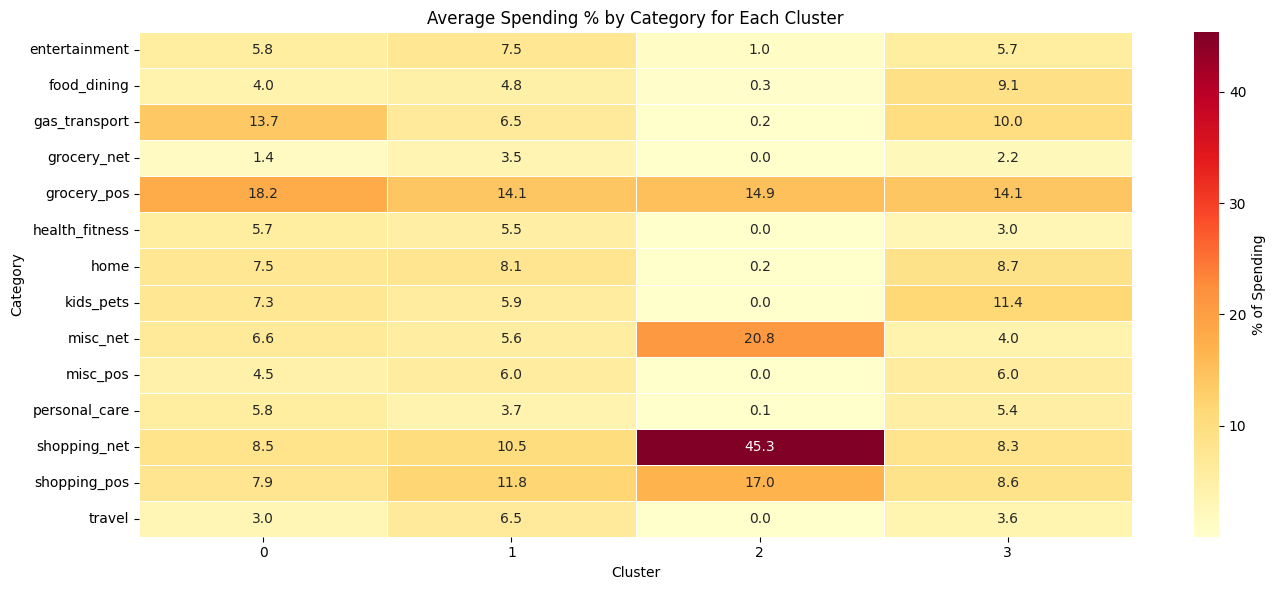

In [ ]:
# Heatmap of cluster spending patterns
plt.figure(figsize=(14, 6))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': '% of Spending'})
plt.xlabel('Cluster')
plt.ylabel('Category')
plt.title('Average Spending % by Category for Each Cluster')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/archive/cluster_heatmap.png', dpi=150)
plt.show()

## Heatmap Analysis

- **Cluster 2 (Inconsistent):** Dominated by online shopping (shopping_net 45.3%, misc_net 20.8%). Near zero on groceries, health, travel.
- **Cluster 0 (Average):** Essentials focused — grocery_pos (18.2%), gas_transport (13.7%).
- **Cluster 1 (High Spender):** Most balanced spending across all categories.
- **Cluster 3 (Budget-Conscious):** Family focused — grocery_pos (14.1%), kids_pets (11.4%), gas_transport (10.0%).

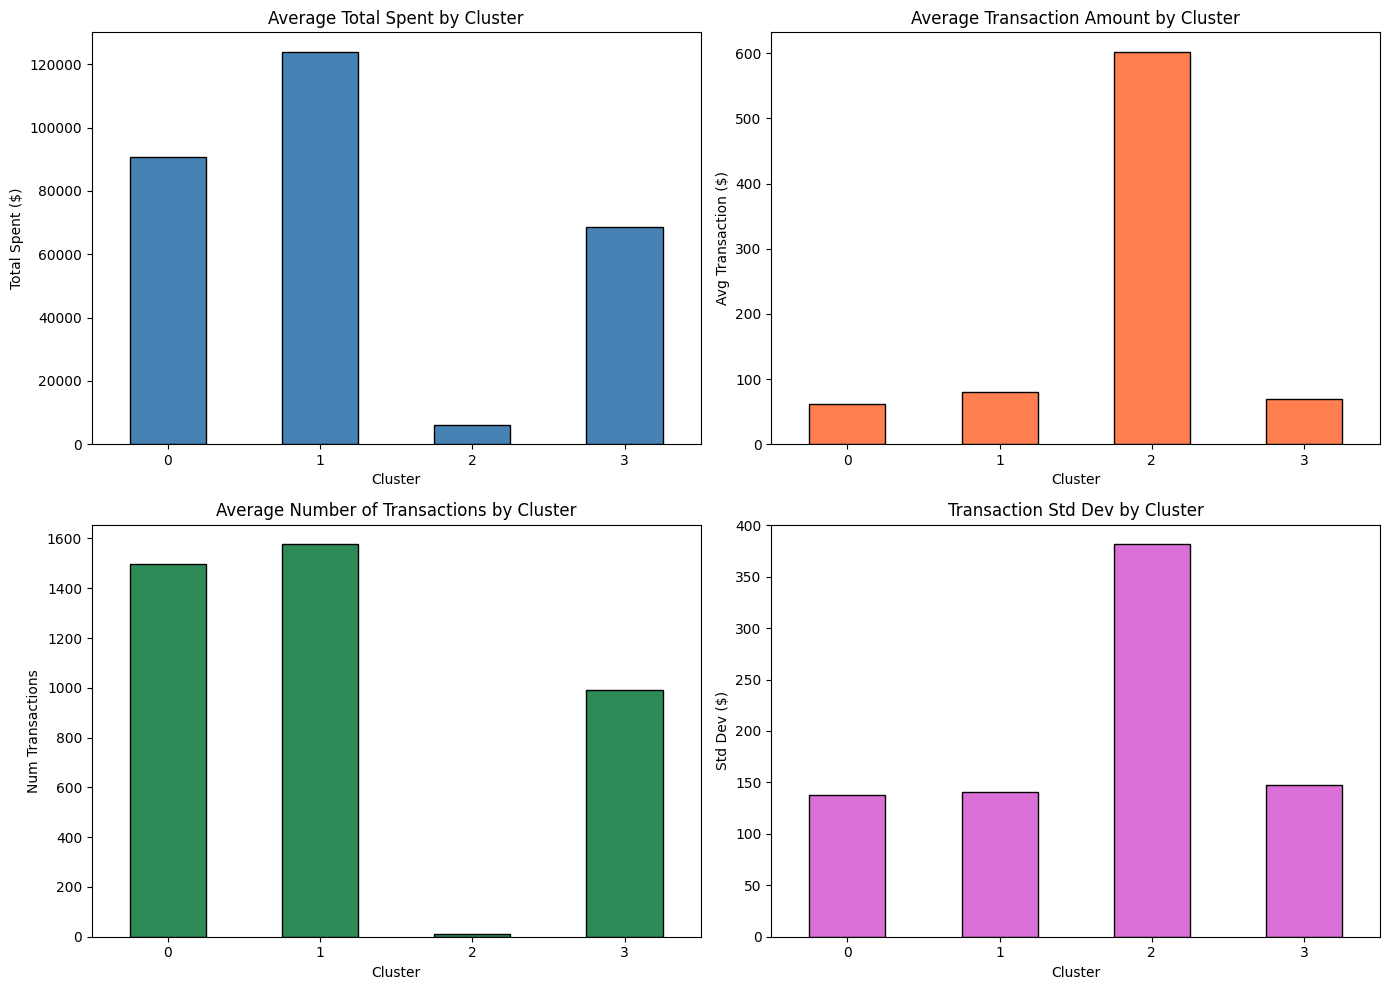

In [ ]:
# Bar chart comparing clusters
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cluster_stats['total_spent'].plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Average Total Spent by Cluster')
axes[0,0].set_ylabel('Total Spent ($)')
axes[0,0].set_xlabel('Cluster')
axes[0,0].tick_params(axis='x', rotation=0)

cluster_stats['avg_transaction'].plot(kind='bar', ax=axes[0,1], color='coral', edgecolor='black')
axes[0,1].set_title('Average Transaction Amount by Cluster')
axes[0,1].set_ylabel('Avg Transaction ($)')
axes[0,1].set_xlabel('Cluster')
axes[0,1].tick_params(axis='x', rotation=0)


cluster_stats['num_transactions'].plot(kind='bar', ax=axes[1,0], color='seagreen', edgecolor='black')
axes[1,0].set_title('Average Number of Transactions by Cluster')
axes[1,0].set_ylabel('Num Transactions')
axes[1,0].set_xlabel('Cluster')
axes[1,0].tick_params(axis='x', rotation=0)

cluster_stats['std_transaction'].plot(kind='bar', ax=axes[1,1], color='orchid', edgecolor='black')
axes[1,1].set_title('Transaction Std Dev by Cluster')
axes[1,1].set_ylabel('Std Dev ($)')
axes[1,1].set_xlabel('Cluster')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/archive/cluster_comparison.png', dpi=150)
plt.show()

## Bar Chart Analysis

- **Total Spent:** Cluster 1 (High Spender) leads at 124k dollars, Cluster 2 (Inconsistent) lowest at 6k dollars.
- **Avg Transaction:** Cluster 2 is an outlier at 602 dollars — 8x higher than others (70 dollars).
- **Num Transactions:** Clusters 0 & 1 have ~1,500 transactions. Cluster 2 has only ~10.
- **Std Deviation:** Cluster 2 has highest variance ($381) — confirms erratic spending behavior.

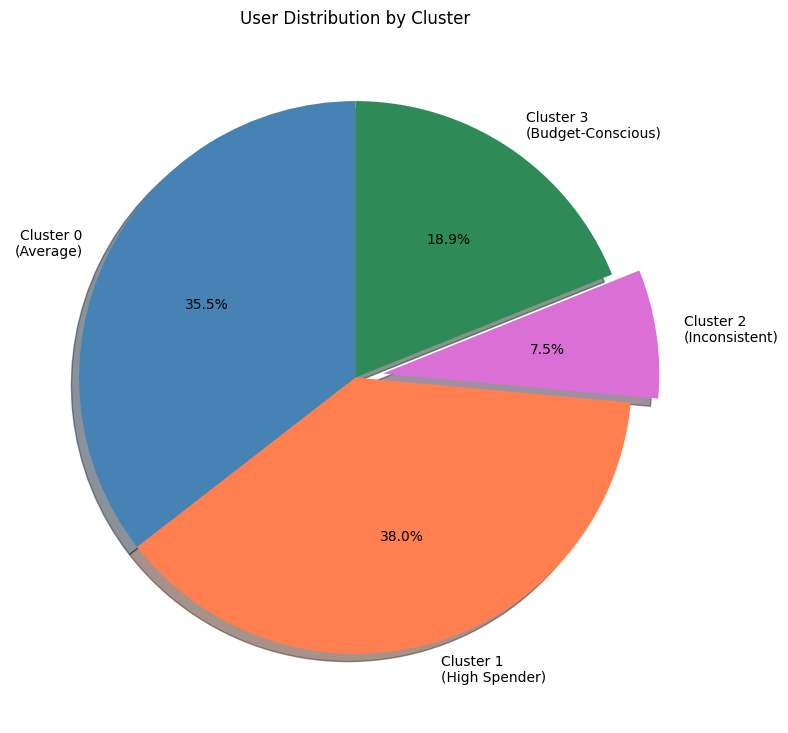

In [ ]:
plt.figure(figsize=(8, 8))
cluster_sizes = user_profile['cluster'].value_counts().sort_index()
labels = ['Cluster 0\n(Average)', 'Cluster 1\n(High Spender)',
          'Cluster 2\n(Inconsistent)', 'Cluster 3\n(Budget-Conscious)']
colors = ['steelblue', 'coral', 'orchid', 'seagreen']
explode = (0, 0, 0.1, 0)  # Highlight the smallest cluster

plt.pie(cluster_sizes, labels=labels, colors=colors, explode=explode,
        autopct='%1.1f%%', startangle=90, shadow=True)
plt.title('User Distribution by Cluster')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/archive/cluster_pie.png', dpi=150)
plt.show()

## User Distribution

- **73.5%** of users are Average (35.5%) or High Spender (38.0%) — predictable spending patterns
- **18.9%** are Budget-Conscious — need saving guidance
- **7.5%** are Inconsistent — small outlier group with erratic behavior

In [ ]:
# Save the trained K-Means model
joblib.dump(kmeans, '/content/drive/MyDrive/archive/kmeans_model.pkl')
print("✅ K-Means model saved!")

# Save the scaler (needed for new users)
joblib.dump(scaler, '/content/drive/MyDrive/archive/kmeans_scaler.pkl')
print("✅ Scaler saved!")

# Save user clusters
user_profile.to_csv('/content/drive/MyDrive/archive/user_clusters.csv')
print("✅ User clusters saved!")

✅ K-Means model saved!
✅ Scaler saved!
✅ User clusters saved!


In [ ]:
# Final Summary
print("K-MEANS CLUSTERING COMPLETE")
print("-"*50)
print(f"Number of users: {len(user_profile)}")
print(f"Number of clusters: {K}")
print(f"\nCluster distribution:")
for cluster_id, name in cluster_names.items():
    count = (clusters == cluster_id).sum()
    pct = count / len(clusters) * 100
    print(f"  Cluster {cluster_id} ({name}): {count} users ({pct:.1f}%)")

K-MEANS CLUSTERING COMPLETE
--------------------------------------------------
Number of users: 983
Number of clusters: 4

Cluster distribution:
  Cluster 0 (Average): 349 users (35.5%)
  Cluster 1 (High Spender): 374 users (38.0%)
  Cluster 2 (Inconsistent): 74 users (7.5%)
  Cluster 3 (Budget-Conscious): 186 users (18.9%)
